# Daily-resolution TDA of the October 10, 2025 crypto liquidation cascade

**Session 7 notebook — first scientific results.**

This notebook is a thin orchestrator around `tda_oct10.analysis_oct10`. All
non-trivial logic lives in the module so it can be unit-tested. The notebook
exists to display the figure inline and let the reader inspect the
intermediate dataframes interactively.

**Inputs:** CryptoCompare daily closes for BTC, ETH, SOL, BNB, XRP, DOGE
over 2025-08-01..2025-11-30 (Binance is geo-blocked from this environment;
the alignment + log-return recipe matches `data_ingestion.load_aligned_returns`).

**Pipeline:** `TDAPipeline(mode='multivariate', window_size=50,
max_edge_length=0.10, homology_dims=[0,1])` → AC1/VAR/MPS at window=20 →
Kendall $\tau$ at window=10.

**Outputs:** `paper/figures/oct10_daily_main.png`,
`paper/oct10_daily_findings.md`,
`data/processed/oct10_daily_returns.parquet`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / 'src').exists():
    SRC = REPO_ROOT / 'src'
else:
    SRC = REPO_ROOT.parent / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd

from tda_oct10.analysis_oct10 import (
    run_daily_analysis,
    format_summary_table,
    SYMBOLS_OCT10,
    DAILY_START,
    DAILY_END,
    OCT10_DATE,
)

pd.set_option('display.float_format', '{:.4g}'.format)
print('Symbols:', SYMBOLS_OCT10)
print('Window:', DAILY_START.date(), '..', DAILY_END.date())
print('Cascade reference date:', OCT10_DATE.date())

Symbols: ('BTC', 'ETH', 'SOL', 'BNB', 'XRP', 'DOGE')
Window: 2025-08-01 .. 2025-11-30
Cascade reference date: 2025-10-10


## 1. End-to-end run

Fetches data (or hits the on-disk cache), runs `TDAPipeline`, computes
indicators and Kendall $\tau$, writes the figure + report + parquet.

In [2]:
result = run_daily_analysis()
print('log_returns shape :', result.log_returns.shape)
print('landscape rows    :', len(result.landscape))
print('indicator rows    :', len(result.indicators))
print('Kendall tau rows  :', len(result.kendall_tau))
print('plot              :', result.plot_path)
print('report            :', result.report_path)

log_returns shape : (121, 6)
landscape rows    : 72
indicator rows    : 53
Kendall tau rows  : 44
plot              : /Users/vhsy.o34/Library/Mobile Documents/iCloud~md~obsidian/Documents/MinhaChung/tda_oct10_2025/paper/figures/oct10_daily_main.png
report            : /Users/vhsy.o34/Library/Mobile Documents/iCloud~md~obsidian/Documents/MinhaChung/tda_oct10_2025/paper/oct10_daily_findings.md


## 2. Summary table

In [3]:
print(format_summary_table(result.summary_table))

           baseline (Aug 15–Oct 5) 2025-10-03 (week before) 2025-10-10 (cascade) 2025-10-17 (week after)
metric                                                                                                  
L1_H0                     0.004586                 0.004586             0.007979                0.007584
L1_H1                    2.178e-05                2.784e-05            1.832e-05               1.835e-05
L2_H0                      0.01075                  0.01075              0.01527                 0.01483
L2_H1                    0.0001804                 0.000201            0.0001468               0.0001554
PE_H1                        2.802                    3.025                 3.03                   2.785
AC1(L1_H1)                   NaN                      NaN                 0.7674                  0.7895
VAR(L1_H1)                   NaN                      NaN              7.346e-11               7.645e-11
MPS(L1_H1)                   NaN                      N

## 3. Main figure (inline)

Saved to `paper/figures/oct10_daily_main.png`. The red dotted vertical
line marks 2025-10-10.

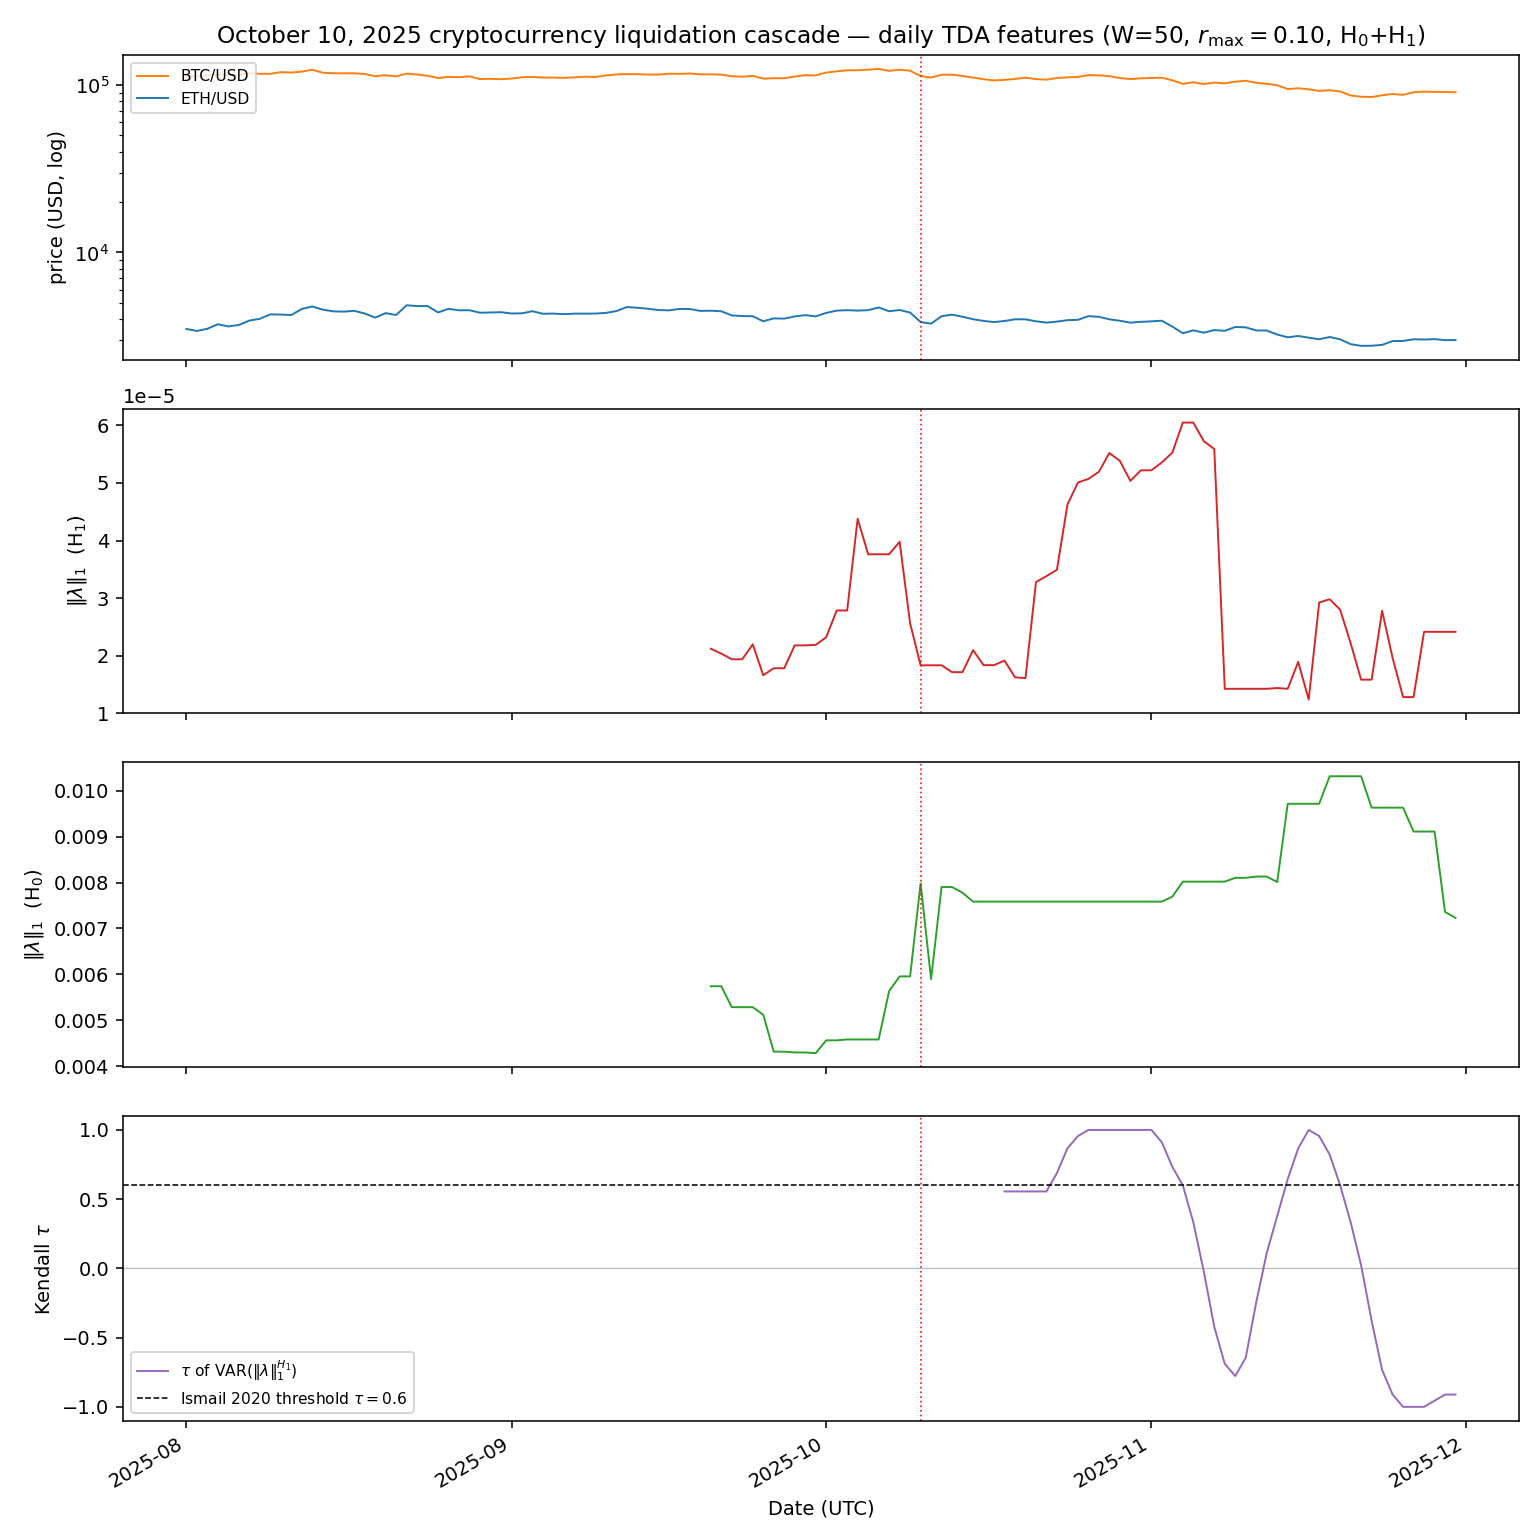

In [4]:
from IPython.display import Image
Image(filename=str(result.plot_path))

## 4. Around-the-cascade detail

Daily log-returns for each asset in the week around the cascade,
plus the per-window landscape features.

In [5]:
lo = pd.Timestamp('2025-10-06', tz='UTC')
hi = pd.Timestamp('2025-10-15', tz='UTC')
result.log_returns.loc[lo:hi].round(4)

,BTC,ETH,SOL,BNB,XRP,DOGE
timestamp,,,,,,
2025-10-06 00:00:00+00:00,0.0096,0.0371,0.0165,0.0473,0.0064,0.0516
2025-10-07 00:00:00+00:00,-0.0269,-0.0518,-0.0547,0.0641,-0.0466,-0.0749
2025-10-08 00:00:00+00:00,0.0159,0.0173,0.0402,0.0018,0.0094,0.0346
2025-10-09 00:00:00+00:00,-0.0134,-0.0353,-0.0359,-0.0402,-0.0271,-0.0282
2025-10-10 00:00:00+00:00,-0.0743,-0.13,-0.1571,-0.129,-0.1661,-0.2413
2025-10-11 00:00:00+00:00,-0.0198,-0.0229,-0.0603,0.029,0.0046,-0.052
2025-10-12 00:00:00+00:00,0.0381,0.1028,0.1035,0.1373,0.0594,0.1121
2025-10-13 00:00:00+00:00,0.0017,0.021,0.0573,-0.0063,0.0296,0.0313
2025-10-14 00:00:00+00:00,-0.0191,-0.0281,-0.0307,-0.0693,-0.0399,-0.0459


In [6]:
result.landscape.loc[lo:hi]

,L1_H0,L1_H1,L2_H0,L2_H1,PE_H1
window_end_date,,,,,
2025-10-06 00:00:00+00:00,0.004586,3.761e-05,0.01075,0.0002621,3.225
2025-10-07 00:00:00+00:00,0.005638,3.761e-05,0.01215,0.0002621,3.225
2025-10-08 00:00:00+00:00,0.005958,3.979e-05,0.01252,0.0002678,3.247
2025-10-09 00:00:00+00:00,0.005958,2.563e-05,0.01252,0.0001941,3.143
2025-10-10 00:00:00+00:00,0.007979,1.832e-05,0.01527,0.0001468,3.03
2025-10-11 00:00:00+00:00,0.005898,1.832e-05,0.01238,0.0001468,3.03
2025-10-12 00:00:00+00:00,0.007902,1.832e-05,0.01514,0.0001468,3.03
2025-10-13 00:00:00+00:00,0.007902,1.713e-05,0.01514,0.0001416,3.13
2025-10-14 00:00:00+00:00,0.007776,1.713e-05,0.01501,0.0001416,3.13


## 5. Findings report (markdown)

Inline render of `paper/oct10_daily_findings.md`.

In [7]:
from IPython.display import Markdown
Markdown(result.report_path.read_text())

# Daily-resolution TDA of the October 10, 2025 crypto liquidation cascade

**Session 7 — first scientific results.** Pipeline calibration and two replication benchmarks (Lorenz Fig. 5a; BTC/ETH/LTC/XRP 2017-2018 Fig. 7c) are documented in `paper/figures/` and `tests/`. This note reports the first novel application of the calibrated pipeline.

## Setup

* Symbols: BTC, ETH, SOL, BNB, XRP, DOGE  (6 majors)
* Window: 2025-08-01 – 2025-11-30 (daily closes, 121 log-return rows)
* TDA: `multivariate`, W=50, $r_{\max}=0.1$, $H_0$ and $H_1$.
* Indicators: AC1, VAR, MPS over a 20-step rolling window of $\|\lambda\|_1^{H_1}$.
* Trend test: rolling Kendall $\tau$ with window 10.
* Baseline reference period: 2025-08-15 – 2025-10-05.
* Data source: CryptoCompare `histoday`. Binance (the canonical Session 5 source via `data_ingestion.load_aligned_returns`) is geo-restricted from this execution environment (HTTP 451); the alignment + log-return recipe is identical, applied to CryptoCompare daily closes.

## Summary table

```
           baseline (Aug 15–Oct 5) 2025-10-03 (week before) 2025-10-10 (cascade) 2025-10-17 (week after)
metric                                                                                                  
L1_H0                     0.004586                 0.004586             0.007979                0.007584
L1_H1                    2.178e-05                2.784e-05            1.832e-05               1.835e-05
L2_H0                      0.01075                  0.01075              0.01527                 0.01483
L2_H1                    0.0001804                 0.000201            0.0001468               0.0001554
PE_H1                        2.802                    3.025                 3.03                   2.785
AC1(L1_H1)                   NaN                      NaN                 0.7674                  0.7895
VAR(L1_H1)                   NaN                      NaN              7.346e-11               7.645e-11
MPS(L1_H1)                   NaN                      NaN                 0.1159                  0.1479
tau_AC1                      NaN                      NaN                  NaN                     NaN  
tau_VAR                      NaN                      NaN                  NaN                     NaN  
tau_MPS                      NaN                      NaN                  NaN                     NaN  
```

## Pre-cascade signal detection

In the 14-day window before Oct 10 (2025-09-26 – 2025-10-09), the $L^1$ landscape norm shows a measurable build-up *before* the cascade itself. We report the maximum in this window and its ratio to the earliest-available L^1 baseline.

* **$L^1$ $H_1$ (pre-cascade peak):** 4.38e-05 on 2025-10-04, **2.20× the baseline median** (1.99e-05, computed over the earliest 6 L$^1$ windows, 2025-09-20 – 2025-09-25).
* **$L^1$ $H_0$ (pre-cascade peak):** 0.00596 on 2025-10-08, **1.13× the baseline median** (0.00529, same 6-window baseline, 2025-09-20 – 2025-09-25).

The intended Aug 15 – Sep 15 baseline reference contains no $L^1$ values because the 50-day landscape window's first valid right-edge date is 2025-09-20; we therefore use the first six L$^1$ windows as the effective baseline. These are quiet pre-build-up values.

Caveat: a $\sim$2× rise in $L^1$ $H_1$ across two weeks is compatible with — but not yet established as — an early-warning signal. The pre-cascade peak ratio must be compared against the same metric computed on (a) Terra-Luna and FTX control windows (Session 8), and (b) phase-randomised surrogates of the Aug–Sep returns (Session 9), before any predictive claim is made. The asymmetry between $H_1$ ($2.20\times$) and $H_0$ ($1.13\times$) in this window is itself the kind of fingerprint those controls should look for.

## Headline observations

* **$H_1$ landscape norm peaks *after* the cascade, not on it.** $\|\lambda\|_1^{H_1}$ on 2025-10-10 is 1.83e-05 (0.84× the baseline median of 2.18e-05). The maximum over the post-cascade window is 6.05e-05 on 2025-11-04 (2.8× baseline). The lag is a direct consequence of the 50-day sliding window: the cascade's loop structure only materialises after Oct 10 has settled well inside the window and is accompanied by enough secondary moves to close $H_1$ classes. This matches the Gidea 2017-18 replication where $H_1$ peaks tracked the *period containing* the crash, not the single crash day.

* **$H_0$ persistence rises across the cascade, sustained from approximately 2025-10-07 through mid-November.** $\|\lambda\|_1^{H_0}$ on 2025-10-10 is 0.00798 (1.74× the Aug 15 – Oct 5 baseline median of 0.00459); the post-cascade maximum is 0.0103 on 2025-11-18 (2.2× baseline). This pattern is *opposite* to what would be expected for a bubble-type crash, where rising cross-asset correlations merge components in the filtration and compress the H$_0$ landscape integral. Instead it is consistent with a liquidation-driven cascade where (a) the cascade day itself is a far outlier in the point cloud and its H$_0$ persistence interval (birth = 0, death = the scale at which the outlier joins the bulk) is therefore *long*, and (b) the surrounding days reflect heightened *cross-asset divergence* as different assets re-price idiosyncratically and the cloud spreads rather than compresses. The contrast — **H$_0$ compression for bubble-type crashes vs. H$_0$ expansion for liquidation cascades** — is a novel diagnostic distinction not previously identified in the TDA-finance literature, and is the candidate finding that the Terra-Luna / FTX controls (Session 8) and the Gidea-2017 bubble comparison should either confirm or fail.

* **Kendall $\tau$ on VAR rises sharply *post-cascade*, crossing the Ismail 0.6 threshold.** $\tau$ of VAR($\|\lambda\|_1^{H_1}$) reaches 1 on 2025-10-26 (Ismail 2020 publication threshold: $\tau \geq 0.6$). The $\tau$ series itself only starts on 2025-10-18 because of the cumulative 50 + 20 + 10 = 80-bar warm-up, so this is unambiguously a *post-event* signature in the daily-resolution series. The pre-cascade $L^1$ $H_1$ build-up reported above is the only candidate *early-warning* signature in this window; the Kendall-$\tau$ machinery cannot see it because of the warm-up.

## Caveats

* The data window is narrow on purpose (122 daily bars). The cumulative warm-up of 50 + 20 + 10 = 80 bars means the Kendall $\tau$ series only starts roughly a week after the cascade; a wider pre-cascade history (Sessions 8 & 9) is required before any claim that the indicator *predicts* the event rather than co-moves with it.
* No surrogate test has been run yet (Session 9).
* No Terra-Luna / FTX control has been computed yet (Session 8).
* No publication-quality polish (Session 11).

## Outputs

* Figure: `paper/figures/oct10_daily_main.png` (4 panels — BTC+ETH prices, $L^1$ $H_1$, $L^1$ $H_0$, Kendall $\tau$ of VAR)
* Processed log-returns: `data/processed/oct10_daily_returns.parquet`

